In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt 
import seaborn as sns

df = pd.read_csv('../../Data/apples_and_oranges.csv')
df.head()

,Weight,Size,Class
0,69,4.39,orange
1,69,4.21,orange
2,65,4.09,orange
3,72,5.85,apple
4,67,4.70,orange


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Weight  40 non-null     int64  
 1   Size    40 non-null     float64
 2   Class   40 non-null     object 
dtypes: float64(1), int64(1), object(1)
memory usage: 1.1+ KB


In [4]:
df['Class'].value_counts()

Class
orange    20
apple     20
Name: count, dtype: int64

In [5]:
x = df[['Weight', 'Size']]
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

model = SVC(kernel='linear')
model.fit(X_train, y_train)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [6]:
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred) * 100, "%")
# Visualisasi hasil


              precision    recall  f1-score   support

       apple       1.00      1.00      1.00         3
      orange       1.00      1.00      1.00         5

    accuracy                           1.00         8
   macro avg       1.00      1.00      1.00         8
weighted avg       1.00      1.00      1.00         8

Accuracy: 100.0 %


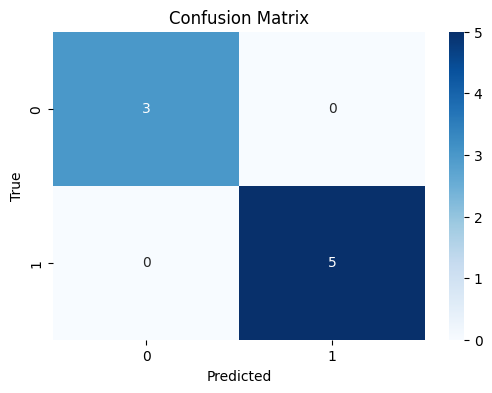

In [7]:
# visulisasi confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

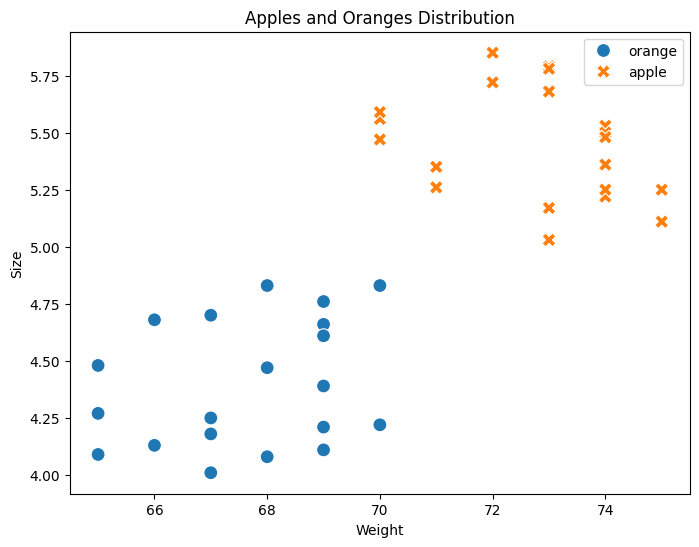

In [17]:
# visualisasi menggunakan sctter plot
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='Weight', y='Size', hue='Class', style='Class', s=100)
plt.title('Apples and Oranges Distribution')
plt.xlabel('Weight')
plt.ylabel('Size')
plt.legend()
plt.show()

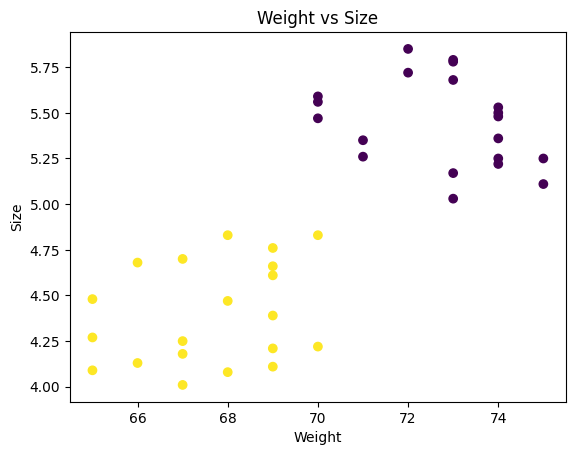

In [9]:
plt.scatter(df['Weight'], df['Size'], c=pd.Categorical(df['Class']).codes)
plt.xlabel('Weight')
plt.ylabel('Size')
plt.title('Weight vs Size')
plt.show()

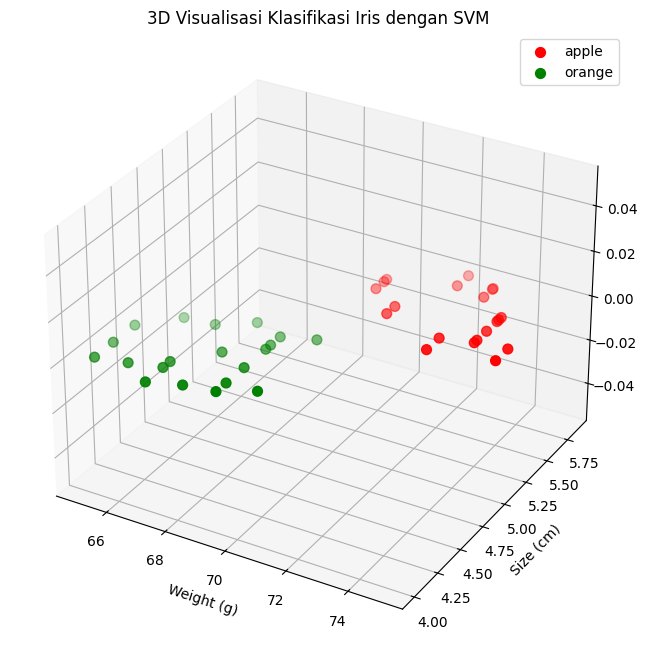

In [19]:
# pastikan ada kolom encoding, buat hanya jika belum ada
from sklearn.calibration import LabelEncoder


if 'Classes_encode' in df.columns:
    enc_col = 'Classes_encode'
else:
    # hanya buat encoder baru jika memang belum ada
    le = LabelEncoder()
    df['Classes_encode'] = le.fit_transform(df['Class'])
    enc_col = 'Classes_encode'

labels = le.classes_
colors = ['r', 'g', 'b']

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

for i, classes in enumerate(labels):
    subset = df[df[enc_col] == i]
    ax.scatter(
        subset['Weight'],
        subset['Size'],
        color=colors[i],
        label=classes,
        s=50
    )

ax.set_xlabel('Weight (g)')
ax.set_ylabel('Size (cm)')
ax.set_title('3D Visualisasi Klasifikasi Iris dengan SVM')
ax.legend()
plt.show()